### PyTorch 기본 사용법

In [4]:
import torch
import numpy as np

a = torch.tensor([1,2,3])  # 1차원 텐서 = 벡터
b = torch.tensor([[1,2,3], [4,5,6]])  # 2차원 텐서 = 행렬

# NumPy
a1 = np.array([[1, 2], [3, 4]])
b1 = np.array([[5, 6], [7, 8]])
print((a1 + b1) @ b1) # 행렬 합과 곱
print()
print(a1 ** 2) # 제곱
print(np.sum(a1)) # 전체 합
print()

# PyTorch
a2 = torch.tensor([[1, 2], [3, 4]])
b2 = torch.tensor([[5, 6], [7, 8]])
print((a2 + b2) @ b2) # 행렬 합과 곱
print(a2 ** 2) # 제곱
print(torch.sum(a2)) # 전체 합

[[ 86 100]
 [134 156]]

[[ 1  4]
 [ 9 16]]
10

tensor([[ 86, 100],
        [134, 156]])
tensor([[ 1,  4],
        [ 9, 16]])
tensor(10)


1. 모델 예측 y_hat = a * x + b
2. MSE 오차 계산
3. 미분
4. 학습률 조절 (하이퍼파라미터 업뎃)

### nn.Linear

Epoch    0 | Loss: 7.0011
Epoch  400 | Loss: 1.0512
Epoch  800 | Loss: 1.0476
Epoch 1200 | Loss: 1.0449
Epoch 1600 | Loss: 1.0428

[학습완료]
학습된 가중치(weight): 0.11242939531803131
학습된 편향(bias)) : 0.744280993938446




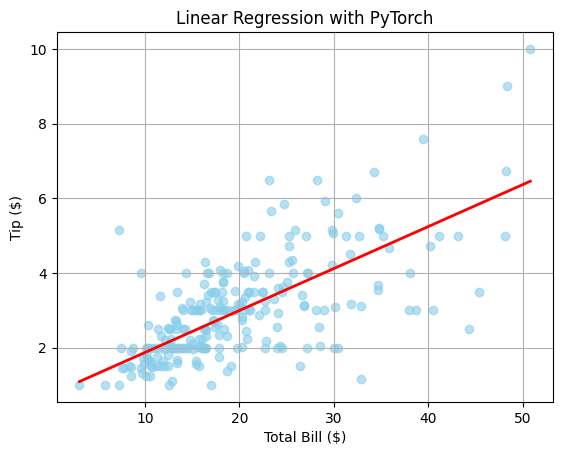

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 준비
tips = sns.load_dataset("tips")

# 입력
X = torch.tensor(tips["total_bill"].values, dtype=torch.float32).reshape(-1,1)
# 출력
y = torch.tensor(tips["tip"].values, dtype=torch.float32).reshape(-1,1)

#ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ
# 모델 정의 - 선형 함수: y = wx + b
model = nn.Linear(1,1)   # 입력 1개, 출력 1개)
#ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ
# 손실함수
criterion = nn.MSELoss()   # MSE 사용
# 옵티마이저
optimizer = optim.SGD(model.parameters(), lr=0.001)   # 옵티마이저 = GD(경사하강법)
#ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ
# 학습 루프
for epoch in range(2000):
    y_hat = model(X)    # 1. 모델 예측값 계산

    loss = criterion(y_hat, y)    # 2. 에러 계산

    # 3. 미분
    optimizer.zero_grad()    # 미분 계산 초기화
    loss.backward()          # 미분 계산 수행 (역전파)

    # 4. 학습률 업데이트
    optimizer.step()         # w 와 b 값이 업데이트

    if epoch % 400 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.4f}")

# 학습 결과 출력
print()
print('[학습완료]')
print(f'학습된 가중치(weight): {model.weight.item()}')
print(f'학습된 편향(bias)) : {model.bias.item()}')
print()
#ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ
# 예측선 준비 (미분 추적 OFF)
with torch.no_grad():
  x_line = torch.linspace(X.min(), X.max(), 100).reshape(-1, 1)
  y_line = model(x_line)

  # 시각화
  plt.scatter(X.numpy(), y.numpy(), color='skyblue', alpha=0.6)
  plt.plot(x_line.numpy(), y_line.numpy(), color='red', linewidth=2)
  plt.title("Linear Regression with PyTorch")
  plt.xlabel("Total Bill ($)")
  plt.ylabel("Tip ($)")
  plt.grid(True)
  print()

### 함수 중첩, Sequential Model

```python
# [중요] 아래 모델은 sigmoid(wx + b) 가 됩니다.
model = nn.Sequential(
    nn.Linear(1, 1),
    nn.Sigmoid()
)
```